## 3. Preprocesamiento y cálculo de features

En esta unidad nos concentraremos en la generación de lags de precio y de targets multi-step, ya que ya se calcularon los retornos logarítmicos y la volatilidad.

In [11]:
LAGS     = [15, 30, 60, 90]   # tamaños de ventana de input (minutos)
HORIZONTE = 7                  # pasos futuros a predecir

def build_dataset(df, lag, horizonte):
    """
    Construye la matriz X (lags de volatilidad) y la matriz Y (targets de volatilidad)
    para un tamaño de lag dado.
    
    Parámetros:
        df        : DataFrame con columnas 'volatilidad' y 'volatility', índice temporal
        lag       : número de lags de la volatilidad a usar como features
        horizonte : número de pasos futuros a predecir
    
    Retorna:
        X : DataFrame de shape (N, lag)    — features: lags de volatilidad
        Y : DataFrame de shape (N, horizonte) — targets: volatilidad futura
        idx : índice temporal correspondiente a cada muestra
    """
    
    #Construcción de X: lags de la volatilidad

    X_dict = {}
    for k in range(1, lag + 1):
        X_dict[f"vol_lag_{k}"] = df["volatility"].shift(k)
    X = pd.DataFrame(X_dict, index=df.index)

    #Construcción de Y: horizonte de volatilidad futura
    Y_dict = {}
    for h in range(1, horizonte + 1):
        Y_dict[f"target_h{h}"] = df["volatility"].shift(-h)
    Y = pd.DataFrame(Y_dict, index=df.index)

    #Combinar y eliminar NaN generados por shift
    #shift(k) genera NaN en las primeras k filas (no hay pasado suficiente)
    #shift(-h) genera NaN en las últimas h filas (no hay futuro disponible)
    combined = pd.concat([X, Y], axis=1).dropna()
    
    X_clean = combined[X.columns]
    Y_clean = combined[Y.columns]
    idx     = combined.index

    return X_clean, Y_clean, idx


#Generamos datasets para cada tamaño de lag
datasets = {}

for lag in LAGS:
    X, Y, idx = build_dataset(df_eda, lag=lag, horizonte=HORIZONTE)
    datasets[lag] = {"X": X, "Y": Y, "idx": idx}
    
    print(f"Lag={lag:3d} min │ X: {X.shape} │ Y: {Y.shape} │"
          f" Desde: {idx[0]} │ Hasta: {idx[-1]}")

Lag= 15 min │ X: (2757916, 15) │ Y: (2757916, 7) │ Desde: 2021-01-01 05:45:00 │ Hasta: 2026-04-01 04:53:00
Lag= 30 min │ X: (2757901, 30) │ Y: (2757901, 7) │ Desde: 2021-01-01 06:00:00 │ Hasta: 2026-04-01 04:53:00
Lag= 60 min │ X: (2757871, 60) │ Y: (2757871, 7) │ Desde: 2021-01-01 06:30:00 │ Hasta: 2026-04-01 04:53:00
Lag= 90 min │ X: (2757841, 90) │ Y: (2757841, 7) │ Desde: 2021-01-01 07:00:00 │ Hasta: 2026-04-01 04:53:00


Veamos un ejemplo de la generación de los lags:

In [12]:
lag_ejemplo = 15
X_ej = datasets[lag_ejemplo]["X"]
Y_ej = datasets[lag_ejemplo]["Y"]

print(f"\nEjemplo con lag={lag_ejemplo} — primera muestra:")
print(f"\nX (features — lags de close):")
print(X_ej.iloc[0].to_frame().T.to_string())
print(f"\nY (targets — volatilidad futura):")
print(Y_ej.iloc[0].to_frame().T.to_string())


Ejemplo con lag=15 — primera muestra:

X (features — lags de close):
                     vol_lag_1  vol_lag_2  vol_lag_3  vol_lag_4  vol_lag_5  vol_lag_6  vol_lag_7  vol_lag_8  vol_lag_9  vol_lag_10  vol_lag_11  vol_lag_12  vol_lag_13  vol_lag_14  vol_lag_15
2021-01-01 05:45:00   0.000624   0.000629   0.000641   0.000636    0.00064   0.000637   0.000696   0.000699   0.000692    0.000689    0.000678     0.00069    0.000684    0.000703    0.000691

Y (targets — volatilidad futura):
                     target_h1  target_h2  target_h3  target_h4  target_h5  target_h6  target_h7
2021-01-01 05:45:00   0.000575   0.000569   0.000579   0.000566   0.000557   0.000591   0.000594


Con todos los datos listos para el modelado, comencemos con el mismo.

## 4. Split temporal, validación cruzada y modelado con Deep Learning

Para el modelado se utilizará `TensorFlow` con el fin de usar la GPU con la que contamos para este proyecto.

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import itertools
import time
import gc
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from scipy import stats as scipy_stats
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# ── GPU ────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth activado — {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

print("GPU disponible :", tf.config.list_physical_devices('GPU'))
print("TensorFlow     :", tf.__version__)

os.makedirs("results", exist_ok=True)

Memory growth activado — 1 GPU(s)
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow     : 2.10.1


Dado que verificamos que TensorFlow detecta la GPU, confirmamos el uso de esta para el proyecto.

Con el fin de mejorar el rendimiento del MLP a implementar, es necesario realizar una búsqueda de hiperparámetros para probar diferentes arquitecturas. Así mismo haremos uso de la librería `timeseries-cv` para la creación de splits de entrenamiento, validación y prueba sin data leakage. En total se hará uso de 5 folds para cada uno de los lags de volatilidad escogidos en la tarea (15, 30, 60 y 90 minutos).

Para esta búsqueda mencionada se probará variando entre 32, 64, 128 y 256 neuronas por capa, variando también entre 1 y 2 capas. Una tercera capa no fue considerada por el alto costo computacional que esto implicaría. Además, consideramos variar entre usar un dropout de 30% o no en las arquitecturas. Así mismo se consideraron 50 épocas tanto para la búsqueda de mejores parámetros como para las validaciones finales, junto con un early stoping con patience de 10.

In [ ]:
# ── Hiperparámetros ────────────────────────────────────────────────────────
LAGS_LIST            = [15, 30, 60, 90]
HORIZONTE            = 7
N_STEPS_JUMP         = 10
EPOCHS_BUSQUEDA      = 50    # épocas para comparar arquitecturas
EPOCHS_ENTRENAMIENTO = 50    # épocas para entrenamiento final por fold
NEURONAS             = [32, 64, 128, 256]
MAX_CAPAS            = 2     # reducido de 3 a 2 para bajar costo computacional
GAP_RATIO_UMBRAL     = 0.15

def get_batch_size(lag):
    """
    Ajusta el batch size según el tamaño del lag para no exceder la VRAM.
    """
    if lag <= 15:   return 2048
    elif lag <= 30: return 1024
    elif lag <= 60: return 512
    else:           return 256

# ── Espacio de búsqueda ────────────────────────────────────────────────────
arquitecturas = []
for n_capas in range(1, MAX_CAPAS + 1):
    for comb in itertools.product(NEURONAS, repeat=n_capas):
        arquitecturas.append(comb)

def dropout_configs(n_capas):
    for mask in range(2 ** n_capas):
        yield tuple(bool((mask >> i) & 1) for i in range(n_capas))

total_configs = sum(2 ** len(a) for a in arquitecturas)
print(f"Arquitecturas             : {len(arquitecturas)}")
print(f"Configs (arch × dropout)  : {total_configs}")
print(f"Runs búsqueda (por lag)   : {total_configs}")
print(f"Runs entrenamiento total  : {len(LAGS_LIST) * 5:,}  "
      f"(4 lags × 5 folds)")

Arquitecturas             : 20
Configs (arch × dropout)  : 72
Runs búsqueda (por lag)   : 72
Runs entrenamiento total  : 20  (4 lags × 5 folds)


In [ ]:
def construir_modelo(arquitectura, dropout_mask, input_dim, output_dim):
    """
    MLP multisalida con Keras.
    input_dim  = número de lags (15 / 30 / 60 / 90)
    output_dim = horizonte = 7
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units, use_dropout in zip(arquitectura, dropout_mask):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if use_dropout:
            model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Dense(output_dim, activation="linear"))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

In [ ]:
from statsmodels.tsa.stattools import bds as bds_test

def calcular_bds(residuos):
    """
    BDS test de independencia serial usando statsmodels.tsa.stattools.bds

    H0: la serie es iid
    p > 0.05 → no se rechaza iid → residuos independientes (buen resultado)
    p < 0.05 → se rechaza iid  → quedan patrones sin capturar

    Parámetros:
        residuos : array 1D de residuos (máx 2000 puntos recomendado)

    Retorna:
        float con el p-value, o np.nan si falla
    """
    residuos = np.asarray(residuos, dtype=np.float64)

    if len(residuos) < 50:
        return np.nan
    if residuos.std() < 1e-10:
        return np.nan

    try:
        res_scaled = (residuos - residuos.mean()) / residuos.std()

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            resultado = bds_test(res_scaled, max_dim=2)

        # resultado es una tupla (estadísticos, p-values)
        # resultado[1] contiene los p-values indexados por dimensión
        pval = resultado[1]

        if np.ndim(pval) == 0:
            return float(pval)
        elif hasattr(pval, '__len__') and len(pval) > 0:
            return float(pval[0])
        return float(pval)

    except Exception as e:
        print(f"      BDS error: {e}")
        return np.nan


LAG = 15 min  |  features = 15  |  targets = 7
Folds generados : 5
Train fold 0    : X=(127291, 15)  y=(127291, 7)
Val   fold 0    : Xcv=(42429, 15)  ycv=(42429, 7)
Test  fold 0    : Xtest=(42429, 15)  ytest=(42429, 7)

Buscando mejor arquitectura (72 configs × 5 folds, 50 épocas máx)...
  Búsqueda fold 1/5...
  Búsqueda fold 2/5...
  Búsqueda fold 3/5...
  Búsqueda fold 4/5...
  Búsqueda fold 5/5...
Búsqueda completada en 47.3 min
Mejor arquitectura : (32, 256)
Dropout mask       : (False, False)
Val RMSE promedio  : 0.198287 ± 0.005233
Gap ratio promedio : 0.0190


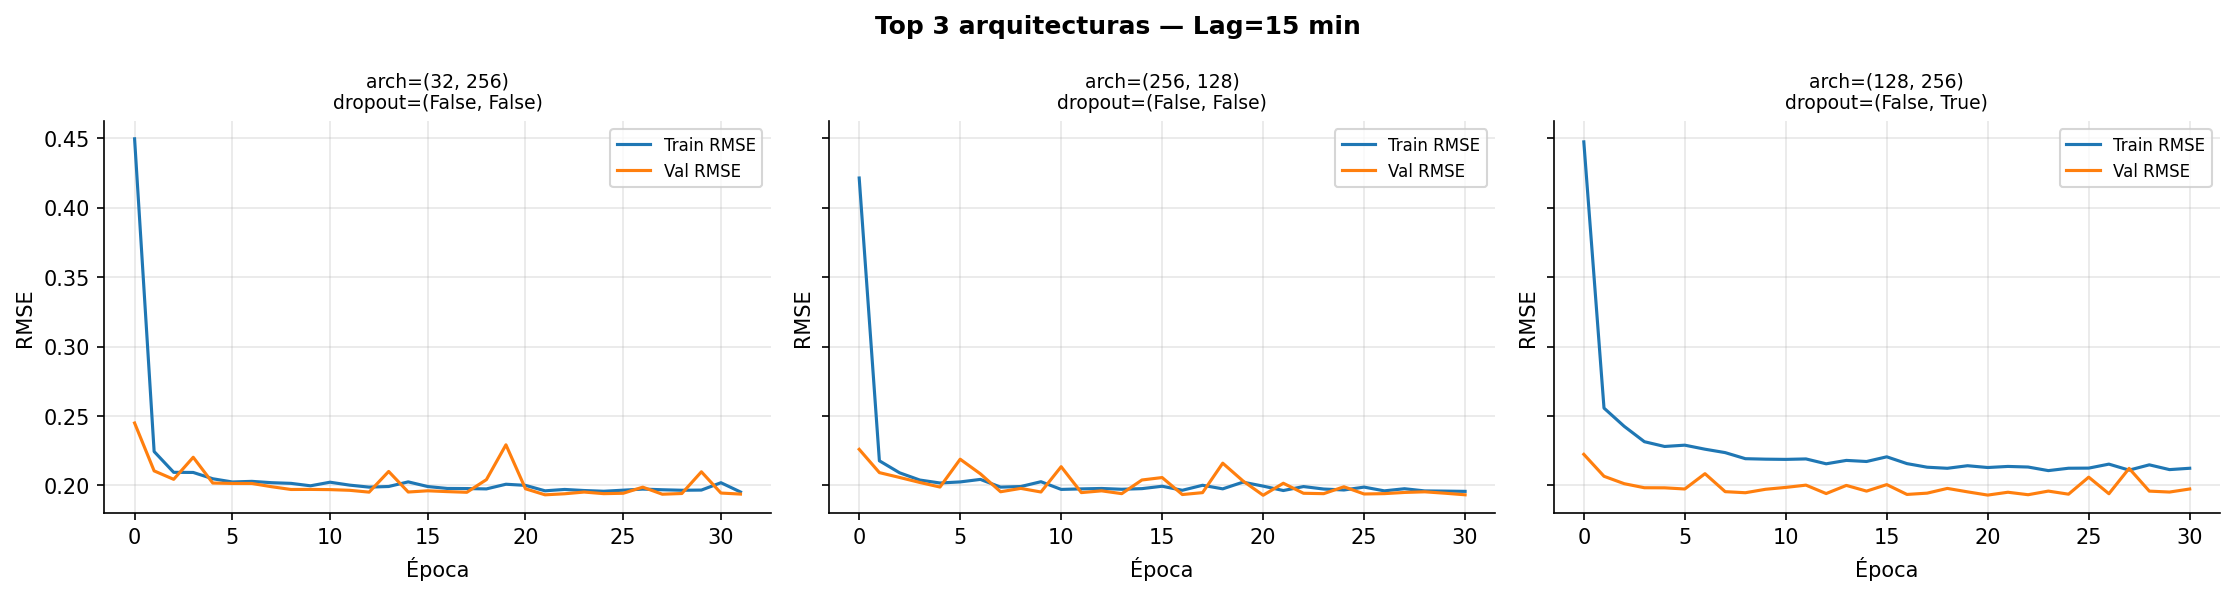


Entrenando 5 folds (50 épocas máx)...
  Fold 1/5 — RMSE h1=0.000052 | BDS p=0.6644 | tiempo=13.5s
  Fold 2/5 — RMSE h1=0.000057 | BDS p=0.6505 | tiempo=17.7s
  Fold 3/5 — RMSE h1=0.000047 | BDS p=0.8088 | tiempo=17.9s
  Fold 4/5 — RMSE h1=0.000053 | BDS p=0.6718 | tiempo=17.5s
  Fold 5/5 — RMSE h1=0.000047 | BDS p=0.6946 | tiempo=15.9s

LAG = 30 min  |  features = 30  |  targets = 7
Folds generados : 5
Train fold 0    : X=(75217, 30)  y=(75217, 7)
Val   fold 0    : Xcv=(25072, 30)  ycv=(25072, 7)
Test  fold 0    : Xtest=(25072, 30)  ytest=(25072, 7)

Buscando mejor arquitectura (72 configs × 5 folds, 50 épocas máx)...
  Búsqueda fold 1/5...
  Búsqueda fold 2/5...
  Búsqueda fold 3/5...
  Búsqueda fold 4/5...
  Búsqueda fold 5/5...
Búsqueda completada en 55.5 min
Mejor arquitectura : (64, 128)
Dropout mask       : (False, False)
Val RMSE promedio  : 0.167871 ± 0.003431
Gap ratio promedio : 0.0231


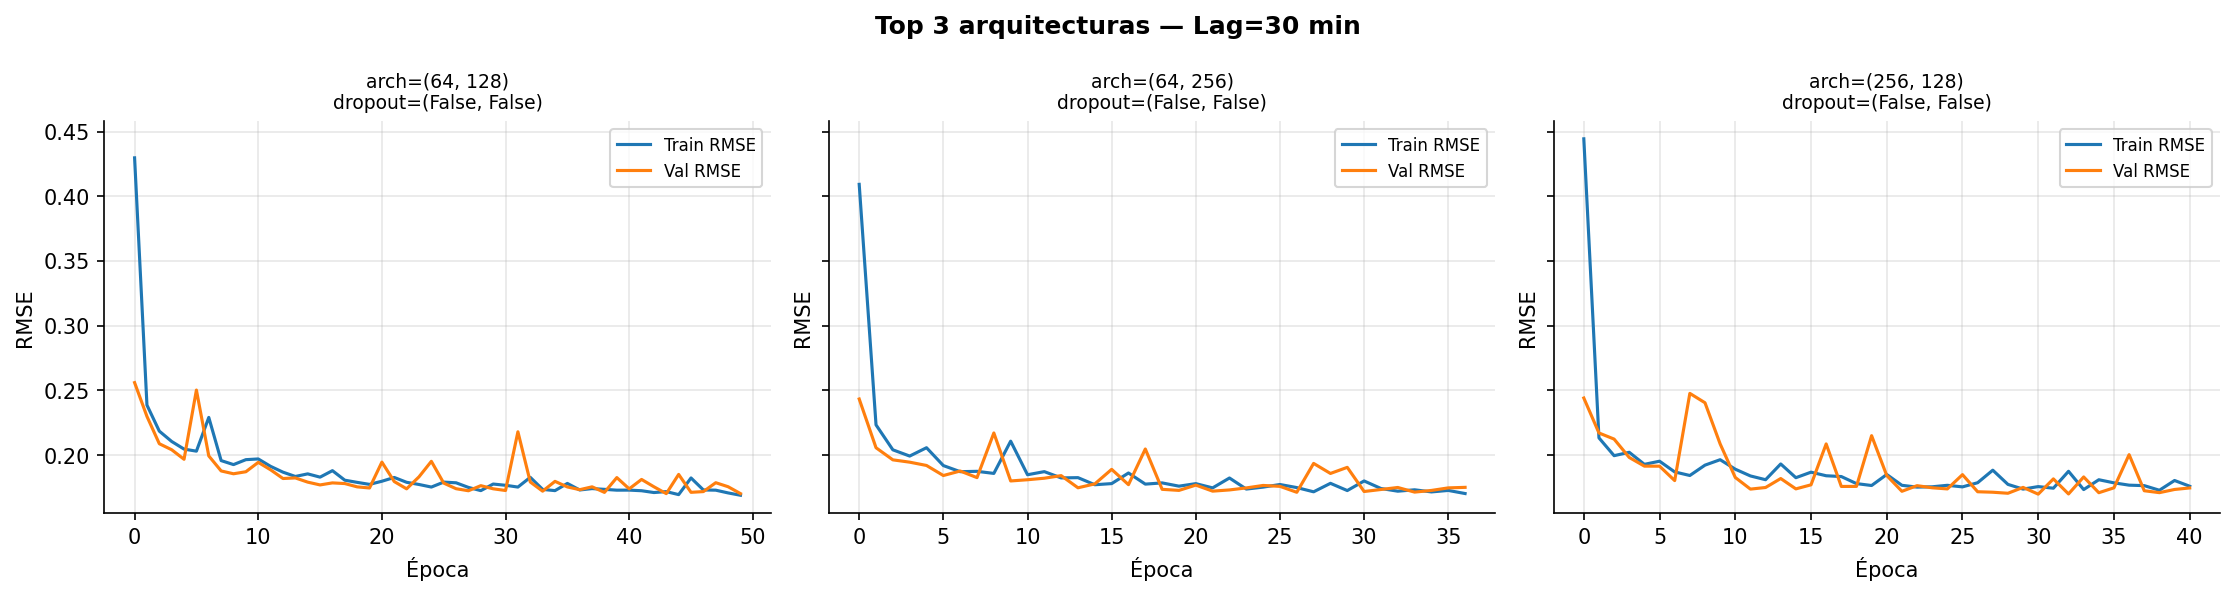


Entrenando 5 folds (50 épocas máx)...
  Fold 1/5 — RMSE h1=0.000045 | BDS p=0.6342 | tiempo=16.3s
  Fold 2/5 — RMSE h1=0.000057 | BDS p=0.9097 | tiempo=14.5s
  Fold 3/5 — RMSE h1=0.000047 | BDS p=0.9725 | tiempo=15.5s
  Fold 4/5 — RMSE h1=0.000044 | BDS p=0.6855 | tiempo=16.6s
  Fold 5/5 — RMSE h1=0.000053 | BDS p=0.3733 | tiempo=16.5s

LAG = 60 min  |  features = 60  |  targets = 7
Folds generados : 5
Train fold 0    : X=(41371, 60)  y=(41371, 7)
Val   fold 0    : Xcv=(13789, 60)  ycv=(13789, 7)
Test  fold 0    : Xtest=(13789, 60)  ytest=(13789, 7)

Buscando mejor arquitectura (72 configs × 5 folds, 50 épocas máx)...
  Búsqueda fold 1/5...
  Búsqueda fold 2/5...
  Búsqueda fold 3/5...
  Búsqueda fold 4/5...
  Búsqueda fold 5/5...
Búsqueda completada en 62.9 min
Mejor arquitectura : (256, 256)
Dropout mask       : (False, False)
Val RMSE promedio  : 0.166281 ± 0.002764
Gap ratio promedio : 0.0454


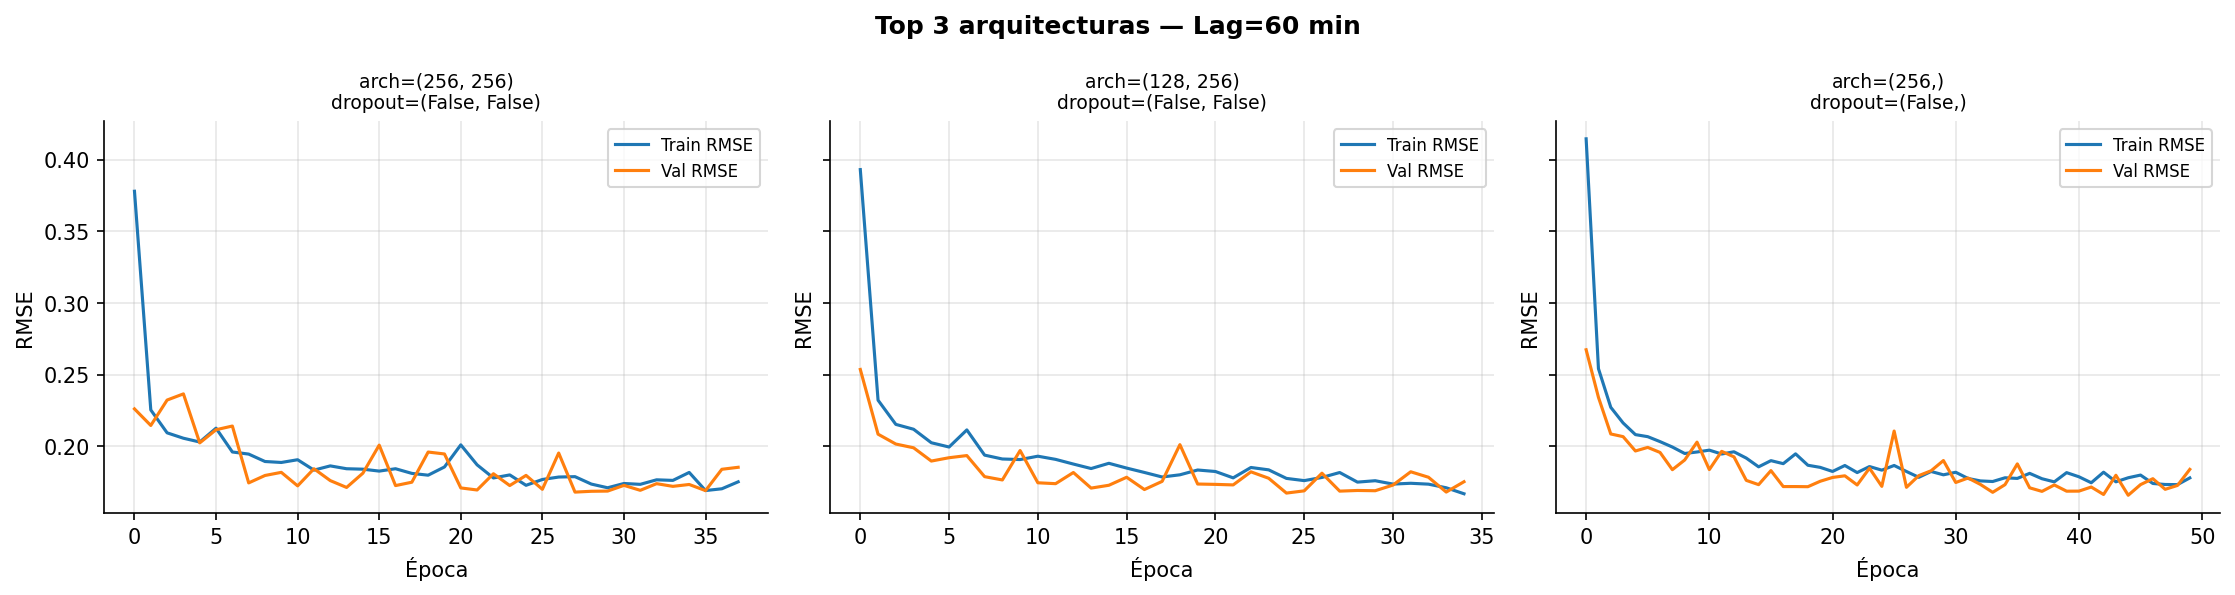


Entrenando 5 folds (50 épocas máx)...
  Fold 1/5 — RMSE h1=0.000044 | BDS p=0.9007 | tiempo=10.2s
  Fold 2/5 — RMSE h1=0.000044 | BDS p=0.9584 | tiempo=12.2s
  Fold 3/5 — RMSE h1=0.000041 | BDS p=0.9245 | tiempo=12.7s
  Fold 4/5 — RMSE h1=0.000041 | BDS p=0.8972 | tiempo=14.4s
  Fold 5/5 — RMSE h1=0.000050 | BDS p=0.7505 | tiempo=10.7s

LAG = 90 min  |  features = 90  |  targets = 7
Folds generados : 5
Train fold 0    : X=(28531, 90)  y=(28531, 7)
Val   fold 0    : Xcv=(9510, 90)  ycv=(9510, 7)
Test  fold 0    : Xtest=(9510, 90)  ytest=(9510, 7)

Buscando mejor arquitectura (72 configs × 5 folds, 50 épocas máx)...
  Búsqueda fold 1/5...
  Búsqueda fold 2/5...
  Búsqueda fold 3/5...
  Búsqueda fold 4/5...
  Búsqueda fold 5/5...
Búsqueda completada en 77.9 min
Mejor arquitectura : (256, 256)
Dropout mask       : (False, False)
Val RMSE promedio  : 0.179954 ± 0.008718
Gap ratio promedio : 0.0720


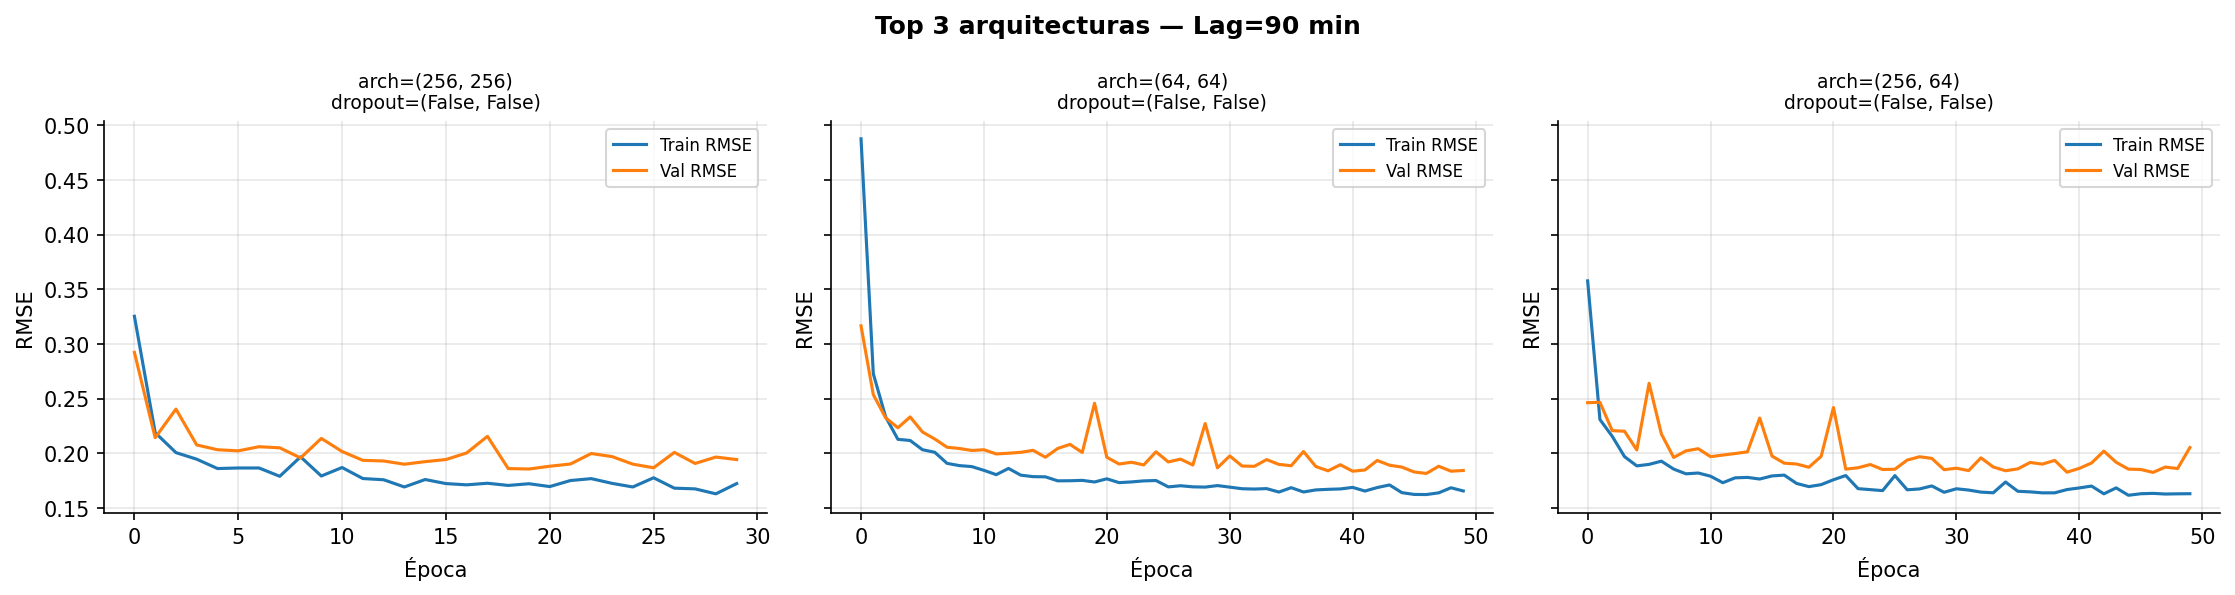


Entrenando 5 folds (50 épocas máx)...
  Fold 1/5 — RMSE h1=0.000046 | BDS p=0.6778 | tiempo=13.8s
  Fold 2/5 — RMSE h1=0.000046 | BDS p=0.5637 | tiempo=11.9s
  Fold 3/5 — RMSE h1=0.000060 | BDS p=0.9288 | tiempo=18.0s
  Fold 4/5 — RMSE h1=0.000056 | BDS p=0.6736 | tiempo=24.3s
  Fold 5/5 — RMSE h1=0.000070 | BDS p=0.8286 | tiempo=10.5s

✓ Entrenamiento completo.


In [17]:
# ── Early stopping ─────────────────────────────────────────────────────────
early_stop_busqueda = tf.keras.callbacks.EarlyStopping(
    monitor="val_rmse", patience=10,
    restore_best_weights=True, verbose=0
)
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_rmse", patience=10,
    restore_best_weights=True, verbose=0
)

# ── Serie de volatilidad ───────────────────────────────────────────────────
vol_series = df_eda["volatility"].values

all_results = {}

for lag in LAGS_LIST:
    print(f"\n{'='*65}")
    print(f"LAG = {lag} min  |  features = {lag}  |  targets = {HORIZONTE}")
    print(f"{'='*65}")

    # ── Split con tsxv ─────────────────────────────────────────────────────
    X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
        vol_series,
        numInputs=lag,
        numOutputs=HORIZONTE,
        numJumps=N_STEPS_JUMP
    )

    n_folds = len(X)
    print(f"Folds generados : {n_folds}")
    print(f"Train fold 0    : X={X[0].shape}  y={y[0].shape}")
    print(f"Val   fold 0    : Xcv={Xcv[0].shape}  ycv={ycv[0].shape}")
    print(f"Test  fold 0    : Xtest={Xtest[0].shape}  ytest={ytest[0].shape}")

# ── Búsqueda de arquitectura — todos los folds ─────────────────────────
    print(f"\nBuscando mejor arquitectura ({total_configs} configs × "
          f"{n_folds} folds, {EPOCHS_BUSQUEDA} épocas máx)...")

    t_busqueda = time.time()

    # Diccionario para acumular val_rmse y gap_ratio por arquitectura+dropout
    acumulado = {}

    for fold_idx in range(n_folds):
        print(f"  Búsqueda fold {fold_idx+1}/{n_folds}...")

        scaler_xb = StandardScaler().fit(X[fold_idx])
        scaler_yb = StandardScaler().fit(y[fold_idx])
        Xtr_b = scaler_xb.transform(X[fold_idx])
        Xvl_b = scaler_xb.transform(Xcv[fold_idx])
        Ytr_b = scaler_yb.transform(y[fold_idx])
        Yvl_b = scaler_yb.transform(ycv[fold_idx])

        for arch in arquitecturas:
            for dmask in dropout_configs(len(arch)):
                key = (arch, dmask)

                model = construir_modelo(arch, dmask,
                                         input_dim=lag,
                                         output_dim=HORIZONTE)
                history = model.fit(
                    Xtr_b, Ytr_b,
                    validation_data=(Xvl_b, Yvl_b),
                    epochs=EPOCHS_BUSQUEDA,
                    batch_size=get_batch_size(lag),
                    callbacks=[early_stop_busqueda],
                    verbose=0
                )
                best_val   = min(history.history["val_rmse"])
                last_train = history.history["rmse"][-1]
                gap_ratio  = abs(last_train - best_val) / (best_val + 1e-8)

                # Acumular resultados por key
                if key not in acumulado:
                    acumulado[key] = {
                        "val_rmse_folds" : [],
                        "gap_ratio_folds": [],
                        "train_curve"    : history.history["rmse"],
                        "val_curve"      : history.history["val_rmse"],
                    }
                acumulado[key]["val_rmse_folds"].append(best_val)
                acumulado[key]["gap_ratio_folds"].append(gap_ratio)

                del model
                tf.keras.backend.clear_session()
                gc.collect()

    print(f"Búsqueda completada en {(time.time()-t_busqueda)/60:.1f} min")

    # ── Construir DataFrame con promedios sobre folds ─────────────────────
    resultados_arch = []
    for (arch, dmask), vals in acumulado.items():
        resultados_arch.append({
            "arquitectura"   : arch,
            "dropout_mask"   : dmask,
            "best_val_rmse"  : np.mean(vals["val_rmse_folds"]),
            "std_val_rmse"   : np.std(vals["val_rmse_folds"]),
            "gap_ratio"      : np.mean(vals["gap_ratio_folds"]),
            "train_curve"    : vals["train_curve"],
            "val_curve"      : vals["val_curve"],
        })

    # ── Selección de mejor arquitectura ───────────────────────────────────
    df_arch    = pd.DataFrame(resultados_arch)
    candidatos = (df_arch[df_arch["gap_ratio"] < GAP_RATIO_UMBRAL]
                  .sort_values("best_val_rmse"))
    if len(candidatos) == 0:
        print("  Sin candidatos con gap_ratio < 0.15 — usando menor val RMSE")
        candidatos = df_arch.sort_values("best_val_rmse")

    mejor      = candidatos.iloc[0]
    best_arch  = mejor["arquitectura"]
    best_dmask = mejor["dropout_mask"]

    print(f"Mejor arquitectura : {best_arch}")
    print(f"Dropout mask       : {best_dmask}")
    print(f"Val RMSE promedio  : {mejor['best_val_rmse']:.6f} "
          f"± {mejor['std_val_rmse']:.6f}")
    print(f"Gap ratio promedio : {mejor['gap_ratio']:.4f}")
    
    # ── Curvas de entrenamiento de los 3 mejores candidatos ───────────────
    fig, axes = plt.subplots(1, min(3, len(candidatos)),
                             figsize=(15, 4), sharey=True)
    if min(3, len(candidatos)) == 1:
        axes = [axes]
    for i, (_, row) in enumerate(candidatos.head(3).iterrows()):
        axes[i].plot(row["train_curve"], label="Train RMSE")
        axes[i].plot(row["val_curve"],   label="Val RMSE")
        axes[i].set_title(f"arch={row['arquitectura']}\n"
                          f"dropout={row['dropout_mask']}", fontsize=9)
        axes[i].set_xlabel("Época")
        axes[i].set_ylabel("RMSE")
        axes[i].legend(fontsize=8)
    fig.suptitle(f"Top 3 arquitecturas — Lag={lag} min", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"results/curvas_busqueda_lag{lag}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

    # ── Entrenamiento fold a fold con la mejor arquitectura ────────────────
    print(f"\nEntrenando {n_folds} folds ({EPOCHS_ENTRENAMIENTO} épocas máx)...")
    fold_results = []

    for fold_idx in range(n_folds):
        t0 = time.time()

        # Scaler fit SOLO con train de este fold
        scaler_x = StandardScaler().fit(X[fold_idx])
        scaler_y = StandardScaler().fit(y[fold_idx])

        X_train = scaler_x.transform(X[fold_idx])
        X_val   = scaler_x.transform(Xcv[fold_idx])
        X_test  = scaler_x.transform(Xtest[fold_idx])
        Y_train = scaler_y.transform(y[fold_idx])
        Y_val   = scaler_y.transform(ycv[fold_idx])
        Y_test  = scaler_y.transform(ytest[fold_idx])

        model = construir_modelo(best_arch, best_dmask,
                                 input_dim=lag,
                                 output_dim=HORIZONTE)
        model.fit(
            X_train, Y_train,
            validation_data=(X_val, Y_val),
            epochs=EPOCHS_ENTRENAMIENTO,
            batch_size=get_batch_size(lag),
            callbacks=[early_stop_final],
            verbose=0
        )

        # ── Predicciones en escala original ───────────────────────────────
        def inv(arr):
            return scaler_y.inverse_transform(arr)

        yhat_train = inv(model.predict(X_train, verbose=0))
        yhat_val   = inv(model.predict(X_val,   verbose=0))
        yhat_test  = inv(model.predict(X_test,  verbose=0))
        Y_train_r  = inv(Y_train)
        Y_val_r    = inv(Y_val)
        Y_test_r   = inv(Y_test)

        # ── Métricas por horizonte ─────────────────────────────────────────
        metricas_h = {}
        for h in range(HORIZONTE):
            real = Y_test_r[:, h]
            pred = yhat_test[:, h]
            mse  = np.mean((real - pred) ** 2)
            metricas_h[f"h{h+1}"] = {
                "MAE" : np.mean(np.abs(real - pred)),
                "RMSE": np.sqrt(mse),
                "MSE" : mse,
                "MAPE": np.mean(
                    np.abs((real - pred) / (np.abs(real) + 1e-8))
                ) * 100,
            }

        # ── BDS test sobre residuos h=1 ────────────────────────────────────
        resid_h1     = Y_test_r[:, 0] - yhat_test[:, 0]
        resid_sample = resid_h1[:2000] if len(resid_h1) > 2000 else resid_h1
        bds_pval     = calcular_bds(resid_sample)

        elapsed = time.time() - t0
        print(f"  Fold {fold_idx+1}/{n_folds} — "
              f"RMSE h1={metricas_h['h1']['RMSE']:.6f} | "
              f"BDS p={bds_pval:.4f} | "
              f"tiempo={elapsed:.1f}s")

        fold_results.append({
            "fold"      : fold_idx + 1,
            "metricas_h": metricas_h,
            "bds_pval"  : bds_pval,
            "yhat_train": yhat_train,
            "yhat_val"  : yhat_val,
            "yhat_test" : yhat_test,
            "Y_train_r" : Y_train_r,
            "Y_val_r"   : Y_val_r,
            "Y_test_r"  : Y_test_r,
        })
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    all_results[lag] = {
        "fold_results"  : fold_results,
        "best_arch"     : best_arch,
        "best_dmask"    : best_dmask,
        "df_arch_search": df_arch,
        "n_folds"       : n_folds,
    }

print("\n✓ Entrenamiento completo.")

Luego del entrenamiento, almacenamos el mejor modelo conseguido (considerando el menor RMSE promedio sobre h=1, ..., 7 en el conjunto de prueba) en un .joblib y .keras para ser utilizado posteriormente en el MLOps.

In [18]:
import joblib

# ── Identificar el mejor lag y fold a nivel global ─────────────────────────
# Criterio: menor RMSE promedio sobre h=1..7 en test
mejor_global = {
    "lag"          : None,
    "fold_idx"     : None,
    "rmse_promedio": np.inf,
}

for lag in LAGS_LIST:
    for fold_idx, fr in enumerate(all_results[lag]["fold_results"]):
        rmse_promedio = np.mean([
            fr["metricas_h"][f"h{h}"]["RMSE"]
            for h in range(1, HORIZONTE + 1)
        ])
        if rmse_promedio < mejor_global["rmse_promedio"]:
            mejor_global["lag"]           = lag
            mejor_global["fold_idx"]      = fold_idx
            mejor_global["rmse_promedio"] = rmse_promedio

lag_best  = mejor_global["lag"]
fold_best = mejor_global["fold_idx"]

print(f"Mejor modelo global:")
print(f"  Lag              : {lag_best} min")
print(f"  Fold             : {fold_best + 1}")
print(f"  RMSE promedio    : {mejor_global['rmse_promedio']:.6f}")
print(f"  Arquitectura     : {all_results[lag_best]['best_arch']}")
print(f"  Dropout          : {all_results[lag_best]['best_dmask']}")

# ── Reentrenar el mejor modelo para guardarlo ──────────────────────────────
X_b, y_b, Xcv_b, ycv_b, _, _ = split_train_val_test_groupKFold(
    vol_series,
    numInputs=lag_best,
    numOutputs=HORIZONTE,
    numJumps=N_STEPS_JUMP
)

scaler_x_best = StandardScaler().fit(X_b[fold_best])
scaler_y_best = StandardScaler().fit(y_b[fold_best])

X_train_best = scaler_x_best.transform(X_b[fold_best])
X_val_best   = scaler_x_best.transform(Xcv_b[fold_best])
Y_train_best = scaler_y_best.transform(y_b[fold_best])
Y_val_best   = scaler_y_best.transform(ycv_b[fold_best])

modelo_final = construir_modelo(
    all_results[lag_best]["best_arch"],
    all_results[lag_best]["best_dmask"],
    input_dim=lag_best,
    output_dim=HORIZONTE
)

modelo_final.fit(
    X_train_best, Y_train_best,
    validation_data=(X_val_best, Y_val_best),
    epochs=EPOCHS_ENTRENAMIENTO,
    batch_size=get_batch_size(lag_best),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_rmse", patience=10,
        restore_best_weights=True, verbose=0
    )],
    verbose=0
)

# ── Guardar en .keras y .joblib ────────────────────────────────────────────
modelo_final.save("results/mejor_modelo.keras")
joblib.dump(modelo_final,  "results/mejor_modelo.joblib")
joblib.dump(scaler_x_best, "results/mejor_modelo_scaler_x.joblib")
joblib.dump(scaler_y_best, "results/mejor_modelo_scaler_y.joblib")

meta = {
    "lag"          : lag_best,
    "fold"         : fold_best + 1,
    "rmse_promedio": mejor_global["rmse_promedio"],
    "arquitectura" : all_results[lag_best]["best_arch"],
    "dropout"      : all_results[lag_best]["best_dmask"],
    "horizonte"    : HORIZONTE,
}
joblib.dump(meta, "results/mejor_modelo_meta.joblib")

print(f"\nArchivos guardados en results/:")
print(f"  mejor_modelo.keras")
print(f"  mejor_modelo.joblib")
print(f"  mejor_modelo_scaler_x.joblib")
print(f"  mejor_modelo_scaler_y.joblib")
print(f"  mejor_modelo_meta.joblib")

del modelo_final
tf.keras.backend.clear_session()
gc.collect()

Mejor modelo global:
  Lag              : 60 min
  Fold             : 2
  RMSE promedio    : 0.000081
  Arquitectura     : (256, 256)
  Dropout          : (False, False)
INFO:tensorflow:Assets written to: ram://942ea807-9b8d-4968-995b-880294bb369d/assets

Archivos guardados en results/:
  mejor_modelo.keras
  mejor_modelo.joblib
  mejor_modelo_scaler_x.joblib
  mejor_modelo_scaler_y.joblib
  mejor_modelo_meta.joblib


6111